In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
from pathlib import Path
from datetime import datetime
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
weather_data_variables = ["DATE","visibility"]
visibility_bins = [0, 1, 4, 9, 100]
visibility_labels = ["Fog", "Poor", "Moderate", "Good"]

vessel_type_bins = [-1,19,29,30,32,33,34,35,36,37,39,49,50,51,52,53,54,55,57,58,59,69,79,89,99]
vessel_type_labels = ["Not available", "WIG",
                      "Fishing", "Towing",
                      "Dredging or underwater ops", "Diving ops", 
                      "Military ops", "Sailing", 
                      "Pleasure Craft", "Reserved", 
                      "HSC", "Pilot Vessel",
                      "Search and Rescue vessel", "Tug",
                      "Port Tender", "Anti-pollution equipment",
                      "Law Enforcement", "Spare - Local Vessel",
                      "Medical Transport", "Noncombatant ship",
                      "Passenger", "Cargo",
                      "Tanker", "Other"]

### Load data

In [ ]:
# Load AIS data
ais_df = pd.read_parquet("../data/study_area/entrance.parquet")
ais_df["VesselTypeName"] = pd.cut(
    ais_df["VesselType"],
    bins= vessel_type_bins,
    labels=vessel_type_labels
)

# Load weather data
weather_df = pd.read_csv(
    "../data/weather_data/GHCNh_USW00012923_2022.psv", 
    delimiter="|",
    parse_dates=["DATE"],
    usecols= weather_data_variables
)
weather_df["visibility_cat"] = pd.cut(
    weather_df["visibility"],
    bins=visibility_bins,
    labels=visibility_labels
)
print(weather_df.sample(30))

                    DATE  visibility visibility_cat
295  2022-01-13 07:00:00         NaN            NaN
8102 2022-12-10 16:00:00         NaN            NaN
6738 2022-10-13 03:00:00         NaN            NaN
3463 2022-05-25 15:00:00         NaN            NaN
6761 2022-10-14 16:00:00         NaN            NaN
2139 2022-03-31 04:00:00         NaN            NaN
765  2022-02-01 21:00:00         NaN            NaN
2244 2022-04-04 13:00:00         NaN            NaN
8489 2022-12-27 05:00:00         NaN            NaN
5833 2022-09-05 05:00:00         NaN            NaN
5211 2022-08-08 19:00:00         NaN            NaN
2624 2022-04-20 11:00:00         NaN            NaN
7751 2022-11-25 12:00:00         NaN            NaN
2911 2022-05-02 10:00:00         NaN            NaN
6244 2022-09-22 10:00:00         NaN            NaN
8089 2022-12-10 03:00:00         NaN            NaN
3112 2022-05-10 20:00:00         NaN            NaN
4751 2022-07-19 05:00:00         NaN            NaN
584  2022-01

### Join AIS and weather data

In [879]:
merged_df = pd.merge_asof(
    ais_df.sort_values("BaseDateTime"),
    weather_df.sort_values("DATE"),
    left_on="BaseDateTime",
    right_on="DATE",
    direction="nearest",
    tolerance=pd.Timedelta("1h")
)
list_of_nulls = [sum(merged_df[c].isnull()) for c in merged_df.columns]

for i, x in enumerate(merged_df.columns):
    print(x, list_of_nulls[i])
    

MMSI 0
BaseDateTime 0
LAT 0
LON 0
SOG 0
COG 0
Heading 0
VesselName 20
IMO 431475
CallSign 1850
VesselType 27075
Status 4394
Length 82403
Width 246509
Draft 582306
Cargo 4425
TransceiverClass 0
VesselTypeName 27075
DATE 222756
visibility 271366
visibility_cat 271770


### Data Cleaning

In [880]:
# Removing duplicates if any
merged_df.drop_duplicates(subset=["MMSI", "BaseDateTime"])

# Remove missing values for SOG and visibility
before = len(merged_df)
merged_df = merged_df.dropna(subset=["SOG", "visibility"])
print(f"Removed {before-len(merged_df)} rows")
# Removing near zero and too high speeds for entrance area
merged_df = merged_df[(merged_df["SOG"] > 0.5) & (merged_df["SOG"] < 30)]

Removed 271366 rows


### Add important columns to merged data

In [881]:
merged_df["Date_month"] = merged_df["BaseDateTime"].dt.to_period("M").dt.start_time
#merged_df["Date_day"]
merged_df["Date_hour"] = merged_df["BaseDateTime"].dt.floor("h")

In [882]:
print("Original df rows:",len(merged_df))
print("Rows with zero length:", len(merged_df[merged_df["Length"] == 0]))

Original df rows: 388629
Rows with zero length: 496


In [883]:
merged_df.dtypes

MMSI                         int64
BaseDateTime        datetime64[us]
LAT                        float64
LON                        float64
SOG                        float64
COG                        float64
Heading                    float64
VesselName                     str
IMO                            str
CallSign                       str
VesselType                 float64
Status                     float64
Length                     float64
Width                      float64
Draft                      float64
Cargo                      float64
TransceiverClass               str
VesselTypeName            category
DATE                datetime64[us]
visibility                 float64
visibility_cat            category
Date_month          datetime64[us]
Date_hour           datetime64[us]
dtype: object

In [884]:
traffic_by_visibility = merged_df.groupby("visibility_cat")["MMSI"].nunique().reset_index(name="unique_vessels")

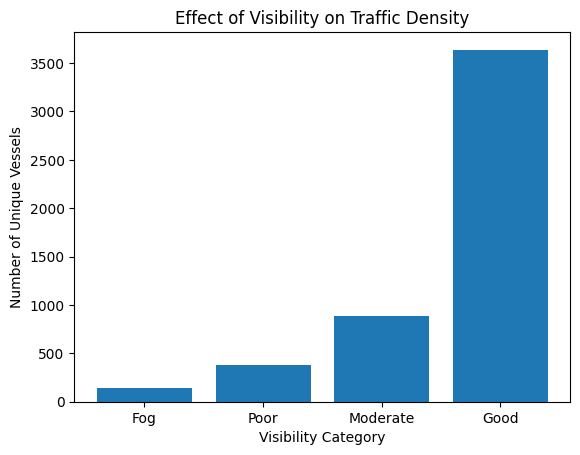

In [885]:
plt.bar(traffic_by_visibility["visibility_cat"], traffic_by_visibility["unique_vessels"])
plt.xlabel("Visibility Category")
plt.ylabel("Number of Unique Vessels")
plt.title("Effect of Visibility on Traffic Density")
plt.show()

In [886]:
temporal_density_hr = merged_df.groupby(['Date_hour', 'visibility_cat'])['MMSI'].nunique().reset_index(name='unique_vessels')
temporal_density_mt = merged_df.groupby(['Date_month', 'visibility_cat'])['MMSI'].nunique().reset_index(name='unique_vessels')


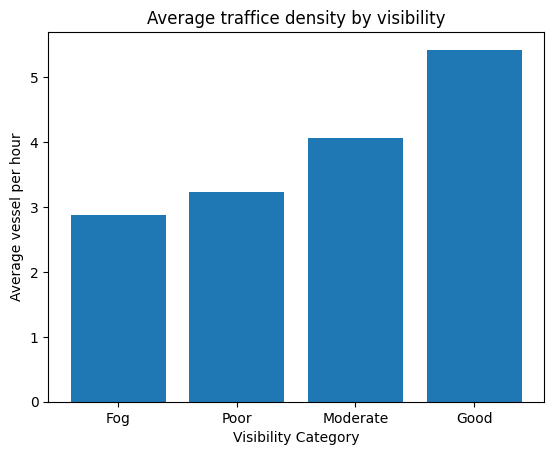

In [887]:
avg_density = temporal_density_hr.groupby("visibility_cat")["unique_vessels"].mean().reset_index(name="avg_vessels")
plt.bar(avg_density["visibility_cat"],avg_density["avg_vessels"])
plt.xlabel("Visibility Category")
plt.ylabel("Average vessel per hour")
plt.title("Average traffice density by visibility")
plt.show()

In [888]:
visibility_values = avg_density.set_index("visibility_cat")["avg_vessels"]

print(visibility_values)
good = visibility_values["Good"]
fog = visibility_values["Fog"]

percent_drop = ((good - fog) / good) * 100
print(f"Traffic drop from Good to Fog: {percent_drop:.2f}%")

visibility_cat
Fog         2.872727
Poor        3.228682
Moderate    4.065858
Good        5.425132
Name: avg_vessels, dtype: float64
Traffic drop from Good to Fog: 47.05%


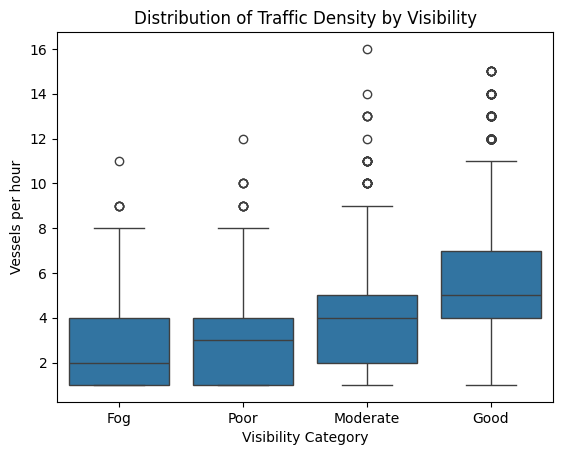

In [889]:
sns.boxplot(data=temporal_density_hr, x="visibility_cat", y="unique_vessels")
plt.xlabel("Visibility Category")
plt.ylabel("Vessels per hour")
plt.title("Distribution of Traffic Density by Visibility")
plt.show()

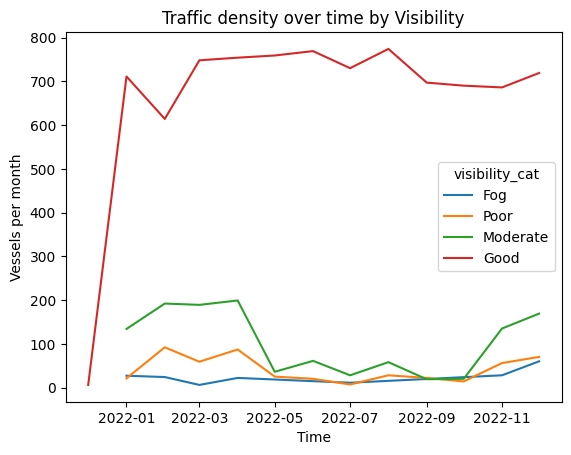

In [890]:
sns.lineplot(data=temporal_density_mt, x="Date_month", y="unique_vessels", hue="visibility_cat")
plt.xlabel("Time")
plt.ylabel("Vessels per month")
plt.title("Traffic density over time by Visibility")
plt.show()

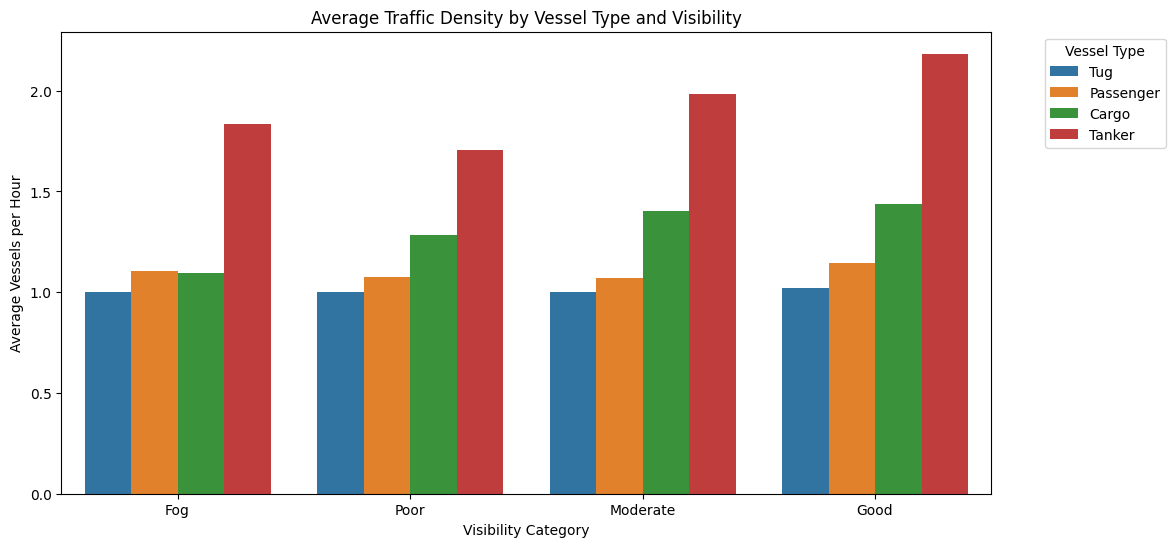

In [891]:
interested_vessel_types = ["Passenger", "Cargo", "Tanker", "Tug"]

filtered_df = merged_df[merged_df["VesselTypeName"].isin(interested_vessel_types)].copy()
filtered_df["VesselTypeName"] = filtered_df["VesselTypeName"].cat.remove_unused_categories()

temporal_density_hr_vessel = (
    filtered_df.groupby(["Date_hour", "visibility_cat", "VesselTypeName"])["MMSI"]
    .nunique()
    .reset_index(name="unique_vessels")
)

avg_density_vessel = (
    temporal_density_hr_vessel.groupby(["visibility_cat","VesselTypeName"])["unique_vessels"]
    .mean()
    .reset_index(name="avg_vessels")
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=avg_density_vessel,
    x='visibility_cat',
    y='avg_vessels',
    hue='VesselTypeName'
)

plt.xlabel("Visibility Category")
plt.ylabel("Average Vessels per Hour")
plt.title("Average Traffic Density by Vessel Type and Visibility")
plt.legend(title="Vessel Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

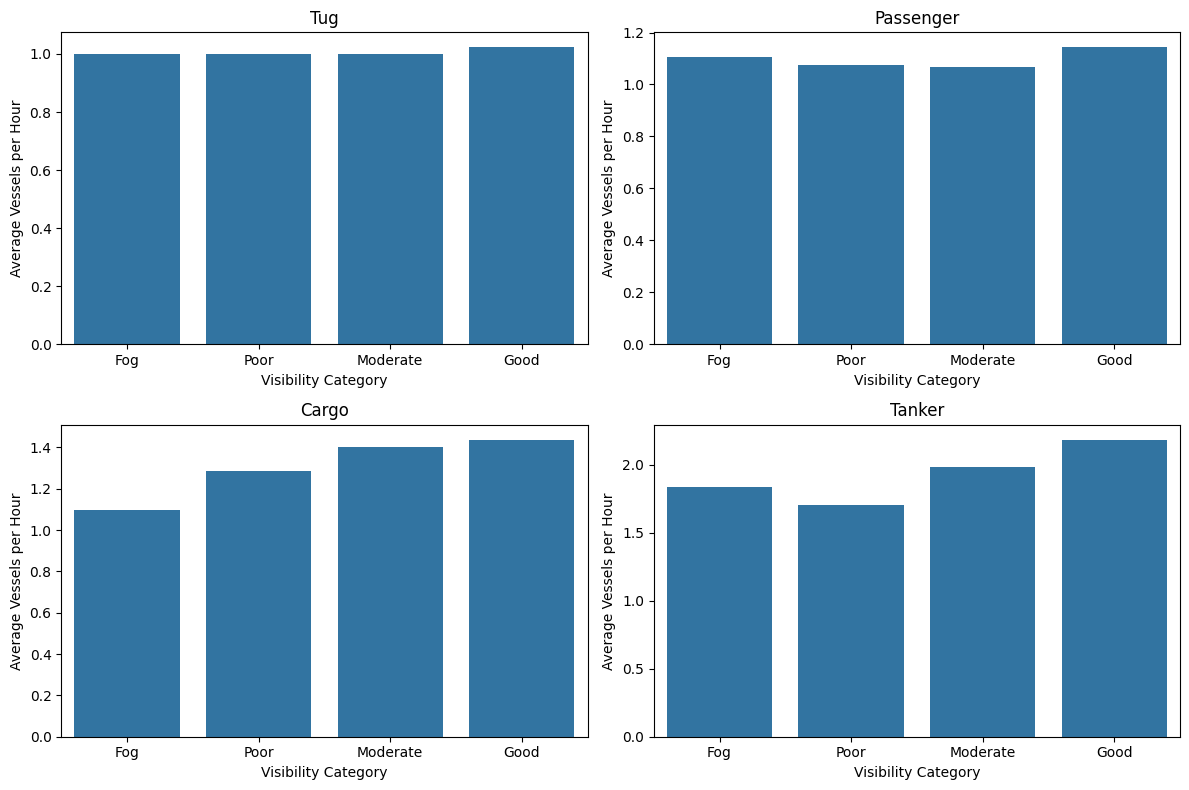

In [892]:
vessel_types = avg_density_vessel["VesselTypeName"].unique()
order = ["Fog", "Poor", "Moderate", "Good"]

fig, axes = plt.subplots(2, 2, figsize=(12,8))

for ax, vessel in zip(axes.flatten(), vessel_types):
    
    data = avg_density_vessel[avg_density_vessel["VesselTypeName"] == vessel]
    
    sns.barplot(
        data=data,
        x="visibility_cat",
        y="avg_vessels",
        order=order,
        ax=ax
    )
    
    ax.set_title(vessel)
    ax.set_xlabel("Visibility Category")
    ax.set_ylabel("Average Vessels per Hour")

plt.tight_layout()
plt.show()

In [893]:
data_A = {
    "vessel":["harry", "james", "ron", "elvis"],
    "date": pd.to_datetime([
        "2022-01-22 09:10",
        "2022-01-22 09:11",
        "2022-01-22 10:01",
        "2022-01-22 11:30"
    ])
}

data_B = {
    "vessel": ["potter", "lilly", "dobby", "sirius"],
    "date": pd.to_datetime([
        "2022-01-22 09:12",
        "2022-01-22 09:17",
        "2022-01-22 09:22",
        "2022-01-22 10:02"
    ])
}

df_A = pd.DataFrame(data_A)
df_B = pd.DataFrame(data_B)

merged_AB = pd.merge_asof(
    df_A.sort_values("date"),
    df_B.sort_values("date"),
    left_on="date",
    right_on="date",
    direction="nearest",
    tolerance=pd.Timedelta("1H")
)
merged_AB

C:\Users\User\AppData\Local\Temp\ipykernel_8364\101930083.py:30: Pandas4Warning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  tolerance=pd.Timedelta("1H")


,vessel_x,date,vessel_y
0,harry,2022-01-22 09:10:00,potter
1,james,2022-01-22 09:11:00,potter
2,ron,2022-01-22 10:01:00,sirius
3,elvis,2022-01-22 11:30:00,NaN


### Analysing SOG

In [894]:
# Calculate speed of each vessel for each hour
hourly_speed_df = (
    merged_df.groupby(["MMSI", "Date_hour"])
      .agg(
          SOG_mean=("SOG", "mean"),
          SOG_median=("SOG", "median"),
          visibility_mean=("visibility", "mean"),
          visibility_cat=("visibility_cat", "first"),
          VesselTypeName=("VesselTypeName", "first")
      )
      .reset_index()
)

print("rows:", len(hourly_speed_df))
#interested_vessel_types = ["Cargo"]
#filtered_df = merged_df[merged_df["VesselTypeName"].isin(interested_vessel_types)].copy()
#filtered_df["VesselTypeName"] = filtered_df["VesselTypeName"].cat.remove_unused_categories()

rows: 44937


In [895]:
def remove_outliers(group):
    q1 = group["SOG_mean"].quantile(0.25)
    q3 = group["SOG_mean"].quantile(0.75)
    iqr = q3-q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr

    return group[(group["SOG_mean"] > lower) & (group["SOG_mean"] < upper)]

In [896]:
# Remove outliers from vessel types
hourly_speed_df = hourly_speed_df.groupby("VesselTypeName").apply(remove_outliers)

In [897]:
speed_type_visibility = (
    hourly_speed_df.groupby(["VesselTypeName","visibility_cat"])["SOG_mean"]
    .mean()
    .reset_index()
)
speed_type_visibility

,VesselTypeName,visibility_cat,SOG_mean
0,Not available,Fog,10.256597
1,Not available,Poor,11.300000
2,Not available,Moderate,9.622178
3,Not available,Good,9.720819
4,WIG,Good,10.083182
5,Fishing,Good,7.782551
6,Towing,Fog,5.535181
7,Towing,Poor,4.203602
8,Towing,Moderate,5.299991
9,Towing,Good,5.572440


In [898]:
baseline = (
    speed_type_visibility[speed_type_visibility["visibility_cat"] == "Good"]
    [["VesselTypeName", "SOG_mean"]]
    .rename(columns={"SOG_mean": "SOG_good_visibility"})
)
baseline
speed_type_visibility = speed_type_visibility.merge(
    baseline,
    on="VesselTypeName",
    how="left"
)
speed_type_visibility["speed_reduction_pct"] = (
    (speed_type_visibility["SOG_good_visibility"] - speed_type_visibility["SOG_mean"])
    / speed_type_visibility["SOG_good_visibility"]
) * 100
speed_type_visibility

,VesselTypeName,visibility_cat,SOG_mean,SOG_good_visibility,speed_reduction_pct
0,Not available,Fog,10.256597,9.720819,-5.511660
1,Not available,Poor,11.300000,9.720819,-16.245352
2,Not available,Moderate,9.622178,9.720819,1.014734
3,Not available,Good,9.720819,9.720819,0.000000
4,WIG,Good,10.083182,10.083182,0.000000
5,Fishing,Good,7.782551,7.782551,0.000000
6,Towing,Fog,5.535181,5.572440,0.668633
7,Towing,Poor,4.203602,5.572440,24.564423
8,Towing,Moderate,5.299991,5.572440,4.889226
9,Towing,Good,5.572440,5.572440,0.000000
